In [1]:
# Notebook complet avec deux approches :
# - Classification séquence-à-séquence avec FLAN-T5
# - Classification avec méthode classique (TF-IDF et logistic regression)

In [2]:
# ============================
# 1. Importation des librairies
# ============================

import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

# Traitement NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# Transformers (HuggingFace)
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EvalPrediction
)


import shap
import evaluate
import torch

C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================
# 2. Chargement des données
# ============================
df= pd.read_csv("bdd_projet6.csv")

# ============================
# 3. Création de variables catégories
# ============================
max_categories = df['product_category_tree'].apply(lambda x: len(x.strip('[]"').split(">>"))).max()
print(f"Nombre maximum de niveaux de catégories : {max_categories}")
def split_categories(text, max_categories):
    """
    Extrait les niveaux de catégories d'une chaîne formatée.
    Paramètres :
    - text (str) : Une chaîne contenant les catégories séparées par '>>', avec des crochets et guillemets.
    - max_categories (int) : Le nombre maximum de niveaux de catégories à prendre en compte.
    Retourne :
    - Une liste contenant les catégories nettoyées et séparées, complétée par "unknown" si nécessaire.
    """
    
    # Vérifier si le texte est bien une chaîne non vide
    if isinstance(text, str) and text:
        # Supprimer les crochets et guillemets au début et à la fin
        clean_text = text.strip('[]"')

        # Séparer en niveaux de catégories
        categories = [cat.strip().lower() for cat in clean_text.split(">>")]

        # Compléter la liste avec "unknown" si le nombre de catégories est inférieur à max_categories
        return categories + ["unknown"] * (max_categories - len(categories))
        # Crée une liste avec unknown comme élément 
        # calcule combien de fois on doit répéter "unknown", afin que la longueur totale de la liste atteigne max_categories.
        # * répète la valeur "unknown" autant de fois que le nombre calculé
    
    # Si le texte est mal formaté ou vide, retourner "unknown" pour chaque catégorie
    return ["unknown"] * max_categories

# Générer dynamiquement les colonnes en fonction du nombre max de niveaux trouvés pour avoir category_1, category_2 etc. 
category_columns = [f'category_{i+1}' for i in range(max_categories)]

# Appliquer la fonction et répartir les catégories sur plusieurs colonnes
df[category_columns] = df['product_category_tree'].apply(split_categories, max_categories=max_categories).apply(pd.Series)


# Afficher un aperçu des résultats

df[['product_category_tree'] + category_columns].head()

# Garde uniquement les colonnes utiles, on renomme pour clarté

df_final = df[["description", "category_1"]].rename(columns={"description": "text", "category_1": "label"})



Nombre maximum de niveaux de catégories : 7


In [4]:
# Dictionnaire de remplacement des labels
label_mapping = {
    "baby care": "baby_care",
    "beauty and personal care": "beauty_and_personal_care",
    "computers": "computers",
    "home decor & festive needs": "home_decor_and_festive_needs",
    "home furnishing": "home_furnishing",
    "kitchen & dining": "kitchen_and_dining",
    "watches": "watches"
}

# Remplacement des noms de labels
df_final['label'] = df_final['label'].replace(label_mapping)

display(df_final[["label"]].value_counts())
display(df_final.head())
display(df_final.shape)

label                       
baby_care                       150
beauty_and_personal_care        150
computers                       150
home_decor_and_festive_needs    150
home_furnishing                 150
kitchen_and_dining              150
watches                         150
Name: count, dtype: int64

,text,label
0,Key Features of Elegance Polyester Multicolor ...,home_furnishing
1,Specifications of Sathiyas Cotton Bath Towel (...,baby_care
2,Key Features of Eurospa Cotton Terry Face Towe...,baby_care
3,Key Features of SANTOSH ROYAL FASHION Cotton P...,home_furnishing
4,Key Features of Jaipur Print Cotton Floral Kin...,home_furnishing


(1050, 2)

In [5]:
# ============================
# 4. Nettoyage des données textuelles
# ============================
def remove_special(text):
    # Le pattern '[^A-Za-z\s]' sélectionne tous les caractères qui ne sont pas des lettres ou espaces.
    return re.sub(r'[^A-Za-z\s]', '', text)

# 2. Convertir en minuscules
def convert_to_lower(text):
    return text.lower()

# 3. Supprimer les espaces multiples et nettoyer les espaces en début/fin
def normalize_spaces(text):
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [6]:
df_final['text'] = df_final['text'].apply(remove_special).apply(convert_to_lower).apply(normalize_spaces)

In [7]:
display(df_final.head())

,text,label
0,key features of elegance polyester multicolor ...,home_furnishing
1,specifications of sathiyas cotton bath towel b...,baby_care
2,key features of eurospa cotton terry face towe...,baby_care
3,key features of santosh royal fashion cotton p...,home_furnishing
4,key features of jaipur print cotton floral kin...,home_furnishing


In [8]:
# ============================
# 5. Encodage Label
# ============================
# Encodage des labels pour pouvoir faire un train_test_split stratifié 
label_encoder = LabelEncoder()
df_final['label_encoded'] = label_encoder.fit_transform(df_final['label'])

In [9]:
# ============================
# 6. Split du dataset
# ============================
train_texts, temp_texts, train_labels, temp_labels = train_test_split(df_final['text'], df_final['label'], test_size=0.3, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, test_size=0.5, random_state=42)

# 70% de train, 15% de val et 15% de test

## Approche AutoModelForSeq2SeqLM

Dataset ≠ Dataframe

Dataset (Huggingface)optimisée pour l'entraînement de modèles :
- plus rapide pour le traitement par lot (batch)
- permet de charger que ce qui est nécessaire
- compatible directement avec Trainer, TrainerSeq2Seq, etc.

In [12]:
# ============================
# 7. Transformation au format Dataset (utilisé par Hugging Face pour un entraînement standard)
# ============================ 
train_df = pd.DataFrame({"text": train_texts, "label": train_labels})
val_df= pd.DataFrame({"text":val_texts, "label": val_labels})
test_df = pd.DataFrame({"text": test_texts, "label": test_labels})

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

print("Shape de l'échantillon de train:", train_df.shape)
print("Shape de l'échantillon de validation:", val_df.shape)
print("Shape de l'échantillon de test:", test_df.shape)

Shape de l'échantillon de train: (735, 2)
Shape de l'échantillon de validation: (157, 2)
Shape de l'échantillon de test: (158, 2)


In [13]:
MODEL_NAME = "google/flan-t5-small"

Dans le contexte de la classification, cette approche traite la tâche comme une génération de texte, où le modèle génère le nom de la classe en sortie.
=> Modèle text to text (génère un texte et non un label)

In [15]:
#charge le modèle T5 (préentraîné) et son tokenizer associé.
tokenizer_seq2seq = T5Tokenizer.from_pretrained(MODEL_NAME)
model_seq2seq = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)


#Un data_collator crée automatiquement des batches de données homogènes en appliquant le padding (de façon dynanmique au moment du batching) 
# pour que tous les textes aient la même taille dans un batch
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer_seq2seq, model=model_seq2seq)

C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [16]:
print(model_seq2seq)

T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
              (wo): 

(source: https://www.devoteam.com/fr/expert-view/attention-is-all-you-need-comprendre-le-traitement-naturel-du-langage-avec-les-modeles-transformers/)
(https://www.datacamp.com/fr/tutorial/how-transformers-work)

---------

1. Input Text
Texte d’entrée sous forme brute

2. Tokenisation
Le texte est découpé en tokens (mots/sous-mots), puis chaque token est transformé en vecteur (embedding)

3. Embedding (partagé input et output)
Chaque token est converti en un vecteur dense de dimension 512 via une table d’embedding partagée entre l’entrée et la sortie.

Vecteur d’embedding = représentation du mot + information sur sa position dans la phrase (via des encodages positionnels = fournir des infos sur la position des tokens).

Ces embeddings sont les entrées du modèle.

4. Encoder (8 blocs) : "Lire et comprendre l’input"
Chaque bloc est composé de 3 éléments principaux :

Self-Attention : chaque token regarde tous les autres pour comprendre le contexte global de la phrase. (Récolte l'infos)
→  mécanisme d’attention des transformers.

Feed Forward Network (FFN) : petit réseau de neurones appliqué indépendamment à chaque token, pour transformer l’information récoltée en une forme plus utile. (Traite l'info)
→ Dans Flan-T5 = Dense-Gated Feed Forward avec activation GELU (au lieu de RELU)

LayerNorm + Dropout :

LayerNorm : stabilise les activations pour un apprentissage plus efficace.

Dropout : désactive des neurones aléatoirement pour éviter le sur-apprentissage (overfitting).

5. Output de l’encoder : les Encodings
L’encoder a transformé les embeddings en représentations riches en contexte : ce sont les Encodings, qui seront utilisés par le décodeur pour générer la réponse.

6. Target Prompt
Le début de la réponse à générer est également tokenisé et transformé en embeddings

7. Decoder (8 blocs) : "Générer la réponse mot par mot"
Chaque bloc du décodeur comprend :

Causal (Masked) Self-Attention : chaque mot généré ne peut regarder que les mots précédents (pour générer de gauche à droite).

Cross-Attention : chaque token de sortie peut regarder tous les encodings de l’entrée pour s’aligner sur ce qui a été compris.

Feed Forward Network, LayerNorm, Dropout : mêmes fonctions que dans l’encodeur.

8. lm_head → logits
Une couche linéaire transforme la sortie du dernier bloc du décodeur en logits, soit une prédiction de scores pour chaque mot du vocabulaire (32 128 possibilités).

9. Softmax → Décodage
Les logits sont passés dans une fonction softmax qui transforme les scores en probabilités.

→ Le mot avec la probabilité la plus élevée est sélectionné comme prochaine sortie.

→ Ce processus est répété jusqu'à générer un token de fin de séquence ou atteindre une longueur maximale.

→ Multi-Head Attention : Le mécanisme d'attention est divisé en plusieurs "têtes", permettant au modèle de capturer différentes relations contextuelles simultanément.

In [18]:
# ============================
# 8. Préparation des données : dans cette approche, les labels restent sous forme de texte
# ============================

# Création d'une instruction claire: "Classe ce produit d'après la desccription" ([] a pu biaiser le modèle)
prefix =("Classify the product into one of the following categories EXACTLY "
    "AS WRITTEN: baby_care, beauty_and_personal_care, computers, "
    "home_decor_and_festive_needs, home_furnishing, kitchen_and_dining, watches.\n"
    "Output only the label from the list.")


def preprocess_function_seq2seq(text, label):
    """
    Prépare chaque échantillon comme paire:
        input_text : texte à classer + consigne
        target_text : label sous forme textuelle
    """
    return {"input_text": prefix + text, "target_text": label} # dictionnaire 

# Création de la version texte-texte de notre dataset 
# boucle sur chaque paire (texte, label) et applique la fonction preprocess pour former un dictionnaire.
# zip pour combiner les deux liste (text et label) en une séquence de paire texte avec son label
train_data_seq2seq = [preprocess_function_seq2seq(x, y) for x, y in zip(train_texts, train_labels)] 
val_data_seq2seq = [preprocess_function_seq2seq(x, y) for x, y in zip(val_texts, val_labels)]
test_data_seq2seq = [preprocess_function_seq2seq(x, y) for x, y in zip(test_texts, test_labels)]

# Conversion en Dataset utilisable par Hugging Face
train_dataset_seq2seq = Dataset.from_list(train_data_seq2seq)
val_dataset_seq2seq = Dataset.from_list(val_data_seq2seq)
test_dataset_seq2seq = Dataset.from_list(test_data_seq2seq)

In [19]:
# ============================
# 9. Tokenisation des entrées et des cibles
# ============================
def tokenize_function_seq2seq(example):
    """
    Tokenize séparément l’entrée (texte + consigne) et la cible (le label à générer).
    Entrée va dans l'encodeur
    Cible va dans le décodeur
    Le modèle s’entraîne à prédire labels (les ID tokenisés du label textuel).
    """
    inputs = tokenizer_seq2seq(
        example["input_text"], max_length=512, padding="max_length", truncation=True
    )
    targets = tokenizer_seq2seq(
        example["target_text"], max_length=30, padding="max_length", truncation=True
    )
    inputs["labels"] = targets["input_ids"] #doit ajouter label car le modèle Trainer attend à avoir label à chaque échantillon
    return inputs

# Application de la tokenisation sur tout le dataset.
train_dataset_seq2seq = train_dataset_seq2seq.map(tokenize_function_seq2seq, batched=False)
val_dataset_seq2seq = val_dataset_seq2seq.map(tokenize_function_seq2seq, batched=False)
test_dataset_seq2seq = test_dataset_seq2seq.map(tokenize_function_seq2seq, batched=False)

# Mise au format torch pour l'entraînement (bon format pour Trainer de Huggingface)
# Format torch = objet mathématique, le dataset est transformé en Tensors PyTorch
train_dataset_seq2seq.set_format("torch")
val_dataset_seq2seq.set_format("torch")
test_dataset_seq2seq.set_format("torch")


Map: 100%|██████████| 158/158 [00:00<00:00, 710.03 examples/s]


In [20]:
# ============================
# 10. Calcul d'accuracy
# ============================
# EvalPrediction est une classe Hugging Face utilisée pour stocker les résultats d'une évaluation en IDS

def compute_metrics(eval_pred: EvalPrediction):
    """
    Calcule les métriques d’évaluation
    Args:
        eval_pred (EvalPrediction): objet contenant deux éléments :
            - predictions : les sorties générées par le modèle (IDs de tokens)
            - label_ids : les labels cibles sous forme de tokens
    Returns:
        dict: dictionnaire contenant la métrique 'accuracy'
    """
    preds, labels = eval_pred  # décompose l’objet EvalPrediction en deux tableaux preds et labels.
    # reconvertit les IDs en texte grâce au tokenizer
    pred_str = tokenizer_seq2seq.batch_decode(preds, skip_special_tokens=True) # batch_decode transforme une série de sorties (suites d'ID) en texte lisible
    label_str = tokenizer_seq2seq.batch_decode(labels, skip_special_tokens=True) # skip_special_tokens=True enlève les tokens comme pad (espaces blancs)

    # Nettoyage éventuel : certains labels peuvent contenir du padding
    pred_str = [p.strip() for p in pred_str]
    label_str = [l.strip() for l in label_str]

    return {"accuracy": accuracy_score(label_str, pred_str)}

In [21]:
# ============================
# 11. Entrainement du modèle
# ============================

# Paramètres d’entraînement adaptés à une tâche de génération de texte.
training_args_seq2seq = Seq2SeqTrainingArguments(
    output_dir="./results_seq2seq",      # Sauvegarde des checkpoints
    per_device_train_batch_size=4,       # Plus petit batch pour réduire bruit, + meilleur surfit
    per_device_eval_batch_size=4,
    learning_rate=3e-5,                  # Learning rate plus bas plus stable mais plus lent
    num_train_epochs=10,                 # Suffisant pour petit dataset
    weight_decay=0.01,                   # Réduction du surapprentissage
    predict_with_generate=True,          # Obligatoire pour classification seq2seq
    save_strategy="epoch",               # Sauvegarde à chaque epoch
    evaluation_strategy="epoch",         # Évalue automatiquement à la fin de chaque epoch
    logging_strategy="steps",
    logging_steps=20,                    # Log fréquent vu le petit dataset
    logging_dir="./logs_seq2seq",        # Logs TensorBoard
    report_to="tensorboard",             # Pour visualisation
    warmup_steps=50,                     # Lissage initial
    lr_scheduler_type="linear",          # Planning de learning rate simple et robuste
    label_smoothing_factor=0.1,          # Lissage des labels pour éviter l'overfitting (évite surestimer les bons labels)
    save_total_limit=3,                  # Garde les 3 meilleurs checkpoints
    load_best_model_at_end=True,         # Recharge le meilleur modèle selon la metric
    metric_for_best_model="loss"         # Optimisation sur la loss
)

from transformers import EarlyStoppingCallback

trainer_seq2seq = Seq2SeqTrainer(
    model=model_seq2seq,
    args=training_args_seq2seq,
    train_dataset=train_dataset_seq2seq,
    eval_dataset=val_dataset_seq2seq,
    tokenizer=tokenizer_seq2seq,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer_seq2seq.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,6.188600,5.472434,0.203822
2,4.029500,3.837192,0.375796
3,3.040700,2.819252,0.471338
4,2.532700,2.450181,0.630573
5,2.304000,2.233749,0.668790
6,2.166700,2.110037,0.656051
7,2.092900,2.045106,0.726115
8,2.067400,2.018147,0.764331
9,2.020900,1.986265,0.770701
10,2.019600,1.983675,0.783439


C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning

TrainOutput(global_step=1840, training_loss=4.045880560252978, metrics={'train_runtime': 12173.3936, 'train_samples_per_second': 0.604, 'train_steps_per_second': 0.151, 'total_flos': 1366295209574400.0, 'train_loss': 4.045880560252978, 'epoch': 10.0})

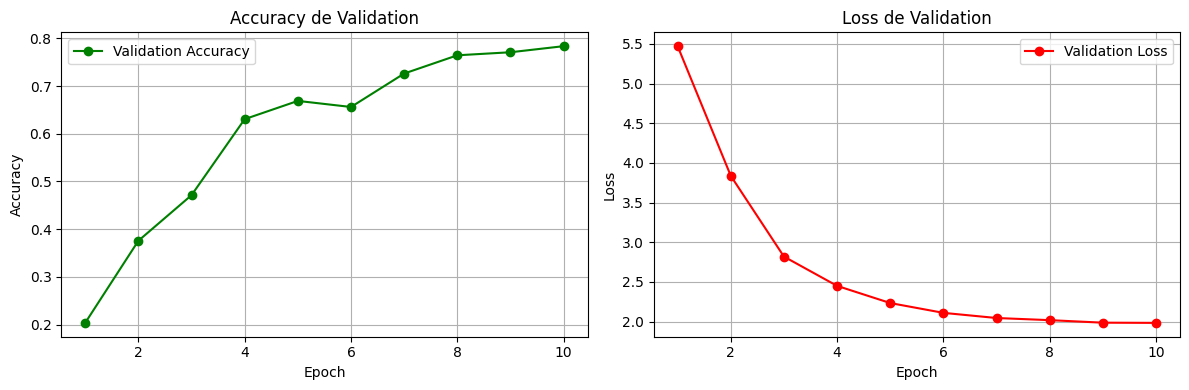

In [22]:
# log_history permet d'accéder à l'historique des logs enregistrés
# log_history est une liste de dictionnaires, chaque dictionnaire correspond à une étape de log et contient les métriques enregistrées 

# Récupère les logs contenant les metrics
logs = trainer_seq2seq.state.log_history

# Extraction des métriques
# extrait l’époque associée à chaque enregistrement qui contient une eval_accuracy.
epochs_acc = [log["epoch"] for log in logs if "eval_accuracy" in log]
# extraction des valeurs d’accuracy de validation à chaque log contenant cette metric.
eval_accuracy = [log["eval_accuracy"] for log in logs if "eval_accuracy" in log]

# Même démarche
epochs_loss = [log["epoch"] for log in logs if "eval_loss" in log]
eval_loss = [log["eval_loss"] for log in logs if "eval_loss" in log]

# Création de deux sous-graphes côte à côte
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Graphe Accuracy
axs[0].plot(epochs_acc, eval_accuracy, label="Validation Accuracy", marker="o", color="green")
axs[0].set_title("Accuracy de Validation")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Accuracy")
axs[0].grid(True)
axs[0].legend()

# Graphe Loss
axs[1].plot(epochs_loss, eval_loss, label="Validation Loss", marker="o", color="red")
axs[1].set_title("Loss de Validation")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()


In [23]:
# ============================
# 12. Entrainement du modèle avec 50 epochs
# ============================

# Paramètres d’entraînement adaptés à une tâche de génération de texte.
training_args_seq2seq = Seq2SeqTrainingArguments(
    output_dir="./results_seq2seq",      # Sauvegarde des checkpoints
    per_device_train_batch_size=4,       # Plus petit batch pour réduire bruit, + meilleur surfit
    per_device_eval_batch_size=4,
    learning_rate=3e-5,                  # Learning rate plus bas plus stable mais plus lent
    num_train_epochs=50,                 # Suffisant pour petit dataset
    weight_decay=0.01,                   # Réduction du surapprentissage
    predict_with_generate=True,          # Obligatoire pour classification seq2seq
    save_strategy="epoch",               # Sauvegarde à chaque epoch
    evaluation_strategy="epoch",         # Évalue automatiquement à la fin de chaque epoch
    logging_strategy="steps",
    logging_steps=20,                    # Log fréquent vu le petit dataset
    logging_dir="./logs_seq2seq",        # Logs TensorBoard
    report_to="tensorboard",             # Pour visualisation
    warmup_steps=50,                     # Lissage initial
    lr_scheduler_type="linear",          # Planning de learning rate simple et robuste
    label_smoothing_factor=0.1,          # Lissage des labels pour éviter l'overfitting (évite surestimer les bons labels)
    save_total_limit=3,                  # Garde les 3 meilleurs checkpoints
    load_best_model_at_end=True,         # Recharge le meilleur modèle selon la metric
    metric_for_best_model="loss"         # Optimisation sur la loss
)


trainer_seq2seq_50 = Seq2SeqTrainer(
    model=model_seq2seq,
    args=training_args_seq2seq,
    train_dataset=train_dataset_seq2seq,
    eval_dataset=val_dataset_seq2seq,
    tokenizer=tokenizer_seq2seq,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

trainer_seq2seq_50.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.924300,1.864976,0.834395
2,1.850300,1.764814,0.859873
3,1.793900,1.751477,0.872611
4,1.742700,1.709880,0.891720
5,1.698900,1.631458,0.910828
6,1.663800,1.617735,0.917197
7,1.640800,1.606952,0.929936
8,1.624800,1.585161,0.929936
9,1.601100,1.573781,0.936306
10,1.587900,1.535793,0.942675


C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning

TrainOutput(global_step=6992, training_loss=1.55393828298189, metrics={'train_runtime': 46515.9498, 'train_samples_per_second': 0.79, 'train_steps_per_second': 0.198, 'total_flos': 5191921796382720.0, 'train_loss': 1.55393828298189, 'epoch': 38.0})

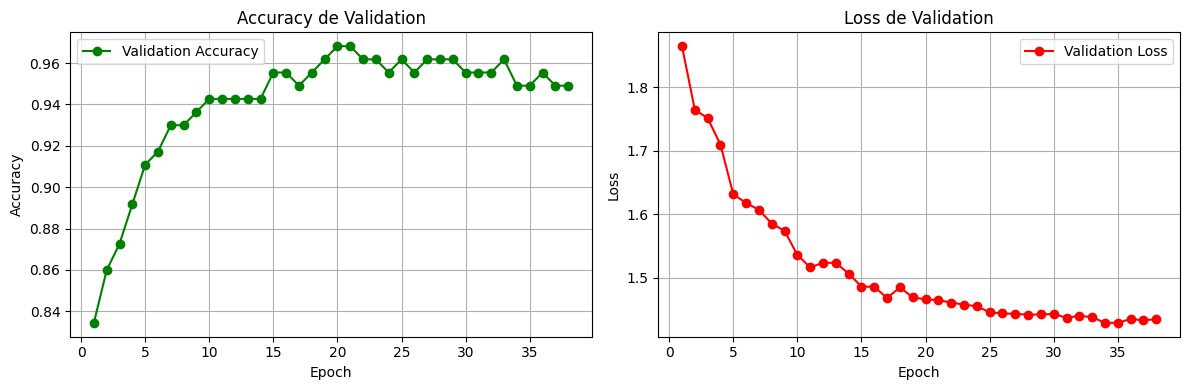

In [24]:
# log_history permet d'accéder à l'historique des logs enregistrés
# log_history est une liste de dictionnaires, chaque dictionnaire correspond à une étape de log et contient les métriques enregistrées 

# Récupère les logs contenant les metrics
logs = trainer_seq2seq_50.state.log_history

# Extraction des métriques
# extrait l’époque associée à chaque enregistrement qui contient une eval_accuracy.
epochs_acc = [log["epoch"] for log in logs if "eval_accuracy" in log]
# extraction des valeurs d’accuracy de validation à chaque log contenant cette metric.
eval_accuracy = [log["eval_accuracy"] for log in logs if "eval_accuracy" in log]

# Même démarche
epochs_loss = [log["epoch"] for log in logs if "eval_loss" in log]
eval_loss = [log["eval_loss"] for log in logs if "eval_loss" in log]

# Création de deux sous-graphes côte à côte
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Graphe Accuracy
axs[0].plot(epochs_acc, eval_accuracy, label="Validation Accuracy", marker="o", color="green")
axs[0].set_title("Accuracy de Validation")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Accuracy")
axs[0].grid(True)
axs[0].legend()

# Graphe Loss
axs[1].plot(epochs_loss, eval_loss, label="Validation Loss", marker="o", color="red")
axs[1].set_title("Loss de Validation")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

In [45]:
# ===============
# 13. # Evaluation 
# ===============

# Génération des prédictions (textes) à partir des entrées.
preds_seq2seq = trainer_seq2seq.predict(test_dataset_seq2seq)
pred_texts_seq2seq = tokenizer_seq2seq.batch_decode(preds_seq2seq.predictions, skip_special_tokens=True)

# Évaluation : on compare les prédictions générées à la cible réelle (label textuel attendu).
true_texts_seq2seq = [x["target_text"] for x in test_data_seq2seq]

print("\n=== Flan-T5 ===")
print("Accuracy:", accuracy_score(true_texts_seq2seq, pred_texts_seq2seq))
print(classification_report(true_texts_seq2seq, pred_texts_seq2seq))

C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(



=== Flan-T5 ===
Accuracy: 0.9240506329113924
                              precision    recall  f1-score   support

                   baby_care       0.85      0.81      0.83        21
    beauty_and_personal_care       1.00      0.93      0.97        15
                   computers       1.00      1.00      1.00        30
home_decor_and_festive_needs       0.83      0.87      0.85        23
             home_furnishing       0.95      0.84      0.89        25
          kitchen_and_dining       0.86      1.00      0.93        19
                     watches       0.96      1.00      0.98        25

                    accuracy                           0.92       158
                   macro avg       0.92      0.92      0.92       158
                weighted avg       0.93      0.92      0.92       158



## TF-IDF 

In [47]:
df_final['text_cleaned'] = df_final['text'].apply(lambda tokens: ' '.join(tokens) if isinstance(tokens, list) else str(tokens))
X = df_final['text_cleaned']
y = df_final['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Encodage des labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

vectorizer= TfidfVectorizer()
X_tfidf_train = vectorizer.fit_transform(X_train)
print("→ Dimensions de la matrice TF-IDF train pour la variable description :", X_tfidf_train.shape)
X_tfidf_val= vectorizer.transform(X_val)
print("→ Dimensions de la matrice TF-IDF val pour la variable description :", X_tfidf_val.shape)
X_tfidf_test = vectorizer.transform(X_test)
print("→ Dimensions de la matrice TF-IDF test pour la variable description :", X_tfidf_test.shape)

→ Dimensions de la matrice TF-IDF train pour la variable description : (735, 4464)
→ Dimensions de la matrice TF-IDF val pour la variable description : (157, 4464)
→ Dimensions de la matrice TF-IDF test pour la variable description : (158, 4464)


In [48]:
from sklearn.model_selection import GridSearchCV

# Définition des hyperparamètres à tester
parameters = {
    'penalty': ['l2'],
    'solver': ['saga', 'lbfgs'],
    'C': [0.05, 0.5, 1]
}

# Création du modèle
model_lr = LogisticRegression(max_iter=1000)

# Recherche des meilleurs hyperparamètres avec validation croisée
clf = GridSearchCV(model_lr, parameters, cv=5, scoring='accuracy')

# Entraînement sur l'ensemble train
clf.fit(X_tfidf_train, y_train)

# Prédiction sur validation
print('Paramètres retenus:',clf.best_params_)
y_pred_val = clf.predict(X_tfidf_val)
acc_val = accuracy_score(y_val, y_pred_val)
print("Accuracy (Validation):", acc_val)
print("Classification Report (Validation):")
print(classification_report(y_val, y_pred_val, target_names=encoder.classes_))

# Prédiction sur test
y_pred_test = clf.predict(X_tfidf_test)
acc_test = accuracy_score(y_test, y_pred_test)
print("Accuracy (Test):", acc_test)
print("Classification Report (Test):")
print(classification_report(y_test, y_pred_test, target_names=encoder.classes_))


Paramètres retenus: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Accuracy (Validation): 0.9490445859872612
Classification Report (Validation):
                              precision    recall  f1-score   support

                   baby_care       0.95      0.83      0.89        24
    beauty_and_personal_care       0.95      0.90      0.93        21
                   computers       1.00      1.00      1.00        22
home_decor_and_festive_needs       0.95      1.00      0.98        21
             home_furnishing       0.90      0.96      0.93        27
          kitchen_and_dining       0.90      1.00      0.95        19
                     watches       1.00      0.96      0.98        23

                    accuracy                           0.95       157
                   macro avg       0.95      0.95      0.95       157
                weighted avg       0.95      0.95      0.95       157

Accuracy (Test): 0.9367088607594937
Classification Report (Test):
                   

## Feature importance - Tf-IDF

### Globale

In [51]:
pd.options.display.max_rows = 70

# 1. Logistic Regression
# Récupérer les noms des features (mots du vocabulaire TF-IDF)
features_names=vectorizer.get_feature_names_out()
# Coefficients du modèle (chaque ligne = une classe)
coefs = clf.best_estimator_.coef_
# Classes cibles
class_labels=clf.best_estimator_.classes_

# Stocker les résultats
feature_importances_lr= []

for class_index, class_label in enumerate(class_labels):
    # Récupérer les coefficients pour cette classe
    class_coefs = coefs[class_index]

    # Récupérer les indices des 10 plus grandes valeurs absolues
    top_indices = np.argsort(np.abs(class_coefs))[::-1][:10]

    # Construire une entrée pour chaque mot important
    for i in top_indices:
        feature_importances_lr.append({
            "Classe": class_label,
            "Mot": features_names[i],
            "Poids (coefficient)": round(class_coefs[i], 2)
        })

# Créer un DataFrame
df_feature_importance = pd.DataFrame(feature_importances_lr)

# Afficher le tableau
display(df_feature_importance)

,Classe,Mot,Poids (coefficient)
0,baby_care,baby,3.00
1,baby_care,girls,1.78
2,baby_care,cotton,1.71
3,baby_care,details,1.48
4,baby_care,fabric,1.31
5,baby_care,sticker,1.24
6,baby_care,offering,1.04
7,baby_care,boys,1.02
8,baby_care,towel,0.91
9,baby_care,ideal,0.88


### Locale

Méthode: 
1. Récupérer le vecteur TF-IDF dense pour la ligne (description) sélectionnée → score Tf-Idf de chaque mot
2. Récupérer les coefficients du modèle pour la classe prédite (vecteur poids par mot)
3. Multiplier les coefficients par le TF-IDF  pour chaque mot → impact des mots sur cette prédiction.
4. Trier ces valeurs en valeur 
5. Afficher les 10 mots avec le plus gros poids

In [172]:
def get_top_features_for_instance(model, vectorizer, X_row, class_label, top_n=10):
    # Coefficients par classe
    class_index = list(model.classes_).index(class_label)
    coef = model.coef_[class_index]
    
    # TF-IDF de l'instance (ligne dense donc .flatten)
    row_tfidf = X_row.toarray().flatten()
    
    # Calcul impact par mot
    impact = coef * row_tfidf
    
    # Indices des top features par impact
    top_indices = np.argsort(np.abs(impact))[-top_n:][::-1]
    feature_names = vectorizer.get_feature_names_out()
    top_features = [(feature_names[i], impact[i]) for i in top_indices]
    return top_features

# Exemple sur l'observation i=13
i = 13
predicted_class = clf.best_estimator_.predict(X_tfidf_test[i])[0]
top_words = get_top_features_for_instance(clf.best_estimator_, vectorizer, X_tfidf_test[i], predicted_class)

print(f"Top 10 mots importants pour l'observation {i} (classe {predicted_class}):")
for word, weight in top_words:
    print(f"{word}: {weight:.4f}")

Top 10 mots importants pour l'observation 13 (classe home_furnishing):
at: 0.8203
cotton: 0.4034
towel: 0.3962
bath: 0.3081
flipkartcom: 0.1119
buy: 0.0540
shipping: 0.0508
genuine: 0.0508
cash: 0.0508
delivery: 0.0499


## Feature importance - FLAN-T5

Pour feature importance FLAN-T5:
- Lime impossible car FLAN T5 est un modèle génératif de texte , LIME attend un vecteur de texte brut ou de format tableau Numpy ce qui n'est pas le cas ici. Le tokenizer de FLAN-T5 crée un vecteur de nombre entier de format 

Deux méthodes possibles à peu près similaires: 

**Méthode Leave One Out: (LOO) — suppression d’un mot à la fois**
- Principe : Mesure la confiance (probabilité ou score) de la prédiction sur le texte complet. On supprime un mot à la fois, on mesure l’impact sur la confiance.
**La différence indique l’importance locale du mot sur la prédiction donnée.**


1. Prédiction originale
- Encode le texte complet (avec le tokenizer).
- Génère la sortie (label prédite).
- Calcule la perte (loss doit être minimisé) entre texte généré et label, multiplie par -1 pour obtenir un score qui doit être maximisé

2. Pour chaque mot i dans le texte
- Supprime le mot i.
- Ré-encode le texte modifié.
- Génère la sortie.

3. Calcule le score pour la même classe prédite initialement.
4. Calcule la différence de score entre la prédiction complète et celle modifiée (diff = base_confidence - new_confidence).

**Plus la différence est grande, plus le mot est important localement pour cette prédiction**
Pour une importance globale (sur l’ensemble du dataset), aggrégation par moyenne, somme par classe ?



**Méthode par masquage**: Même logique que Leave One Out mais au lieu de supprimer le mot on le remplace par un token neutre (pad)

Ici ce sera la méthode Leave One Out qui sera testée


**Rappel**

le format pytorch tokenisé retourne un dictionnaire avec le vecteur tokenise et l'attention_mask :

"le chat dort" :
                
                inputs_ids:tensor([[15,356,984]]) et 

                attention_mask: tensor([[1,1,1,0,0,0]], 
                
                ou 1 = signale qu'il doit prendre en compte le mot et 0 que ce n'est qu'un "pad" pour satisfaire la max_lenght.


### Locale

In [85]:
def explain_prediction_by_word_importance(
    model, tokenizer, input_text, target_label, prefix, max_length=512):
    """
    Analyse l'importance locale de chaque mot dans un texte en utilisant
    la méthode LOO sur la loss de la prédiction.

    Args:
        model: Modèle Flan-T5 entraîné (T5ForConditionalGeneration)
        tokenizer: Tokenizer associé au modèle
        input_text: Description
        target_label: Label que le modèle est censé prédire
        prefix: instruction
        max_new_tokens: Longueur maximale autorisée pour le tokeniseur
    Returns:
        Liste triée des mots et de leur importance décroissante
    """
    # 0. Désactive les comportements d'aléas de l'entrainement (batchnorm, dropout), le modèle s'exécute avec ce qu'il a appris en train
    model.eval()
    
    # 1. Préparation du texte
    full_input = prefix + input_text

    # 2. Tokenisation
    original_inputs = tokenizer(full_input, return_tensors="pt", max_length=max_length, truncation=True)

    # 3. Tokenisation du label (sortie attendue)
    labels = tokenizer(target_label, return_tensors="pt").input_ids
    # target_label est la cat. attendue qui est transformé en IDS 
    # .input_ids permet de récupérer dans le dictionnaire original_inputs seulement la partie inputs_id et non attention_mask

    # 4. Calcul du score original
    with torch.no_grad():
    # pas de calcul de gradient (pas d'entraînement), juste de la prédiction.
        output = model(**original_inputs, labels=labels)
        # ** = permet de décomposer le dictionnaire
        original_score = -output.loss.item()
        # loss.item retourne la loss entre le prédiction et la target_label
        # multiplie par -1 pour obtenir un score à maximiser

    # 5. Boucle de perturbation par suppression de mot (LOO)
    
    # Découpe le texte en mots pour les perturber un par un
    tokens = input_text.split()
    
    word_importances = []  # Stocke le score d’importance pour chaque mot
    
    for i in range(len(tokens)):
        perturbed_text = " ".join(tokens[:i] + tokens[i+1:])     # Suppression d'un mot à la fois: token[:i] tous les mots avant i, tokens[i+1] tous les mots après i
        perturbed_input = prefix + perturbed_text                # Reconstruction avec mot supprimé
        inputs = tokenizer(perturbed_input, return_tensors="pt", # Tokenise l’entrée perturbée 
                           max_length=max_length, truncation=True)

        # Calcule la perte pour cette version modifiée (même logique que pour l'original)
        with torch.no_grad():
            output = model(**inputs, labels=labels)
            perturbed_score = -output.loss.item()

        # 6. Calcul de la différence de score
        delta = original_score - perturbed_score
        # Plus delta est grand plus le mot a une importance

        # Stockage des mots avec leur score
        word_importances.append((tokens[i], delta))

    # Trie les mots par score décroissant
    sorted_importance = sorted(word_importances, key=lambda x: x[1], reverse=True)

    # 7. Affichage : texte et mots les plus importants
    print(f"\n📌 Texte original : {input_text}")
    print(f"🎯 Label prédit : {target_label}")
    print(f"🔍 Mots les plus influents :\n")
    for word, imp in sorted_importance[:10]:
        print(f"{word} ➤ importance: {imp:.4f}")

In [87]:
print(test_dataset_seq2seq)

Dataset({
    features: ['input_text', 'target_text', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 158
})


In [170]:
index = 13
explain_prediction_by_word_importance(
    model=model_seq2seq,
    tokenizer=tokenizer_seq2seq,
    input_text=test_data_seq2seq[index]["input_text"].replace(prefix, ""), # supprime le prefix pour ne pas faire doublon
    target_label=test_data_seq2seq[index]["target_text"],
    prefix=prefix
)



📌 Texte original : buy mandhania cotton bath towel at rs at flipkartcom only genuine products free shipping cash on delivery
🎯 Label prédit : home_furnishing
🔍 Mots les plus influents :

towel ➤ importance: 0.0534
cotton ➤ importance: 0.0352
cash ➤ importance: 0.0126
rs ➤ importance: 0.0113
shipping ➤ importance: 0.0095
at ➤ importance: 0.0047
genuine ➤ importance: 0.0002
products ➤ importance: -0.0016
flipkartcom ➤ importance: -0.0063
only ➤ importance: -0.0073


### Globale

1. Appliquer Leave-One-Out sur un ensemble de textes étiquetés

2. Calculer la moyenne des scores d'importance des mots (ou tokens) par classe cible

=>  Quels mots influencent globalement le plus la prédiction de la classe X ?

In [91]:
from collections import defaultdict
# dictionnaire Python amélioré qui crée automatiquement des valeurs par défaut si une clé n'existe pas.

def aggregate_word_importance_by_class(model, tokenizer, dataset, prefix="", max_length=512, max_samples=None):
    """
    Agrège l’importance des mots pour chaque classe cible (label).
    Utilise Leave-One-Out pour chaque mot du texte.
    
    Args:
        model: Modèle Flan-T5 (T5ForConditionalGeneration)
        tokenizer: Tokenizer associé
        dataset: Liste de dictionnaires avec clés 'input_text' et 'target_text'
        prefix: Instruction
        max_samples: Nombre max d’échantillons à traiter (accélère le traitement)
    
    Retourne:
        Dictionnaire {label: [(mot, importance_moyenne)]}
    """
    model.eval()
    word_scores_per_class = defaultdict(lambda: defaultdict(list))  # {label: {word: [scores]}}

    for idx, example in enumerate(dataset):
        if max_samples and idx >= max_samples:
            break

        input_text = example["input_text"].replace(prefix, "").strip()
        target_label = example["target_text"]
        full_input = prefix + input_text

        # Tokenisation de l’entrée complète et du label
        inputs = tokenizer(full_input, return_tensors="pt", max_length=max_length, truncation=True)
        labels = tokenizer(target_label, return_tensors="pt").input_ids

        with torch.no_grad():
            output = model(**inputs, labels=labels)
            original_score = -output.loss.item()

        tokens = input_text.split()

        for i in range(len(tokens)):
            perturbed_text = " ".join(tokens[:i] + tokens[i+1:])
            perturbed_input = tokenizer(prefix + perturbed_text, return_tensors="pt", max_length=max_length, truncation=True)

            with torch.no_grad():
                output = model(**perturbed_input, labels=labels)
                perturbed_score = -output.loss.item()

            delta = original_score - perturbed_score
            word_scores_per_class[target_label][tokens[i]].append(delta)

    # Moyenne des importances par mot et tri
    aggregated_results = {}
    for label, word_scores in word_scores_per_class.items():
        averaged_scores = [(word, sum(scores) / len(scores)) for word, scores in word_scores.items()]
        sorted_words = sorted(averaged_scores, key=lambda x: x[1], reverse=True)
        aggregated_results[label] = sorted_words

        # Affichage
        print(f"\n📚 Classe: {label}")
        print("Mots les plus influents :")
        for word, score in sorted_words[:10]:
            print(f"{word} ➤ importance moyenne: {score:.4f}")

    return aggregated_results

In [93]:
aggregate_word_importance_by_class(
    model=model_seq2seq,
    tokenizer=tokenizer_seq2seq,
    dataset=test_data_seq2seq,
    prefix=prefix)


📚 Classe: watches
Mots les plus influents :
v ➤ importance moyenne: 0.0025
maserati ➤ importance moyenne: 0.0018
flippd ➤ importance moyenne: 0.0017
partywedding ➤ importance moyenne: 0.0016
features ➤ importance moyenne: 0.0016
boys ➤ importance moyenne: 0.0013
delivery ➤ importance moyenne: 0.0013
girls ➤ importance moyenne: 0.0012
caron ➤ importance moyenne: 0.0011
fighter ➤ importance moyenne: 0.0011

📚 Classe: computers
Mots les plus influents :
vgncre ➤ importance moyenne: 0.0025
hdmi ➤ importance moyenne: 0.0022
buy ➤ importance moyenne: 0.0017
dir ➤ importance moyenne: 0.0011
doraemon ➤ importance moyenne: 0.0011
delivery ➤ importance moyenne: 0.0011
nano ➤ importance moyenne: 0.0010
adsl ➤ importance moyenne: 0.0010
actu ➤ importance moyenne: 0.0009
netgear ➤ importance moyenne: 0.0009

📚 Classe: home_decor_and_festive_needs
Mots les plus influents :
vase ➤ importance moyenne: 0.0232
analog ➤ importance moyenne: 0.0232
wall ➤ importance moyenne: 0.0197
hookah ➤ importance moy

{'watches': [('v', 0.002524103969335556),
  ('maserati', 0.0018427502363920212),
  ('flippd', 0.0017238017171621323),
  ('partywedding', 0.001637553796172142),
  ('features', 0.0016060955822467804),
  ('boys', 0.0013481313362717628),
  ('delivery', 0.0013057563143471878),
  ('girls', 0.001205076773961385),
  ('caron', 0.0011093895882368088),
  ('fighter', 0.0010972637683153152),
  ('olvin', 0.0010933298617601395),
  ('plated', 0.0010234005749225616),
  ('tii', 0.000923952708641688),
  ('decker', 0.0009092334657907486),
  ('fiber', 0.0009085517376661301),
  ('lois', 0.0008663684129714966),
  ('elantra', 0.0008560493588447571),
  ('discounts', 0.0008265646174550056),
  ('tees', 0.0008085817098617554),
  ('lmgy', 0.0007531928519407908),
  ('metal', 0.0006991270929574966),
  ('s', 0.0006920658051967621),
  ('buy', 0.0006793513894081116),
  ('warranty', 0.0006650127470493317),
  ('color', 0.0006511341780424118),
  ('pc', 0.000643901526927948),
  ('hmt', 0.0006058085709810257),
  ('formal', 

## Accuracy

Autre possibilité est d'effectuer la méthode Leave One Out sur l'accuracy.

Car avec la loss :
- Mesure continue de l'importance mais moins facile d'interprétation
- On peut mesurer l'importance même quand la prédiction ne change pas


Alors que LOO avec accuracy: 
- Interprétation binaire : 0 si la prédiction finale ne change pas et 1 si la prédiction finale change
- Beaucoup plus facile d'interprétation mais du coup pas sensible aux petits changements saisit seulement l'importance lorsque la prédiction change

### Locale

In [102]:
def loo_on_accuracy(
    model, tokenizer, input_text, target_label, prefix="", max_length=512):
    """
    Mesure l'importance des mots en évaluant si leur suppression change la prédiction finale.
    Importance = 1 si la prédiction change quand on supprime le mot, sinon 0.
    """

    model.eval()
    full_input = prefix + input_text

    # 1. Prédiction initiale
    original_inputs = tokenizer(full_input, return_tensors="pt", max_length=max_length, truncation=True)
    # original_inputs = {"input_ids": tensor([[12,5685,12 ...]]), "attention_mask": tensor([[1,1,1,0,0,0]])}
    
    with torch.no_grad():
        outputs = model.generate(**original_inputs) # ** sert à décomposer le dictionnaire (input_ids =..., attention_mask=...) et model.generate génère la classe (suite de token IDS)
    original_prediction = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    # ici pas .loss_item mais accède aux inputs_ids de la 1ère et seule ligne [0] et on le décode pour accéder à un texte lisible

    # 2. Perturbation par mot (même logique avec suppression d'un mot)
    tokens = input_text.split()
    word_impacts = []

    for i in range(len(tokens)):
        perturbed_text = " ".join(tokens[:i] + tokens[i+1:])
        full_perturbed = prefix + perturbed_text
        perturbed_inputs = tokenizer(full_perturbed, return_tensors="pt", max_length=max_length, truncation=True)
        
        with torch.no_grad():
            outputs = model.generate(**perturbed_inputs)
        perturbed_prediction = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

        # 3. Impact binaire sur l’accuracy
        changed = int(perturbed_prediction != original_prediction)
        word_impacts.append((tokens[i], changed))

    # 4. Résultat
    print(f"\n📌 Texte original : {input_text}")
    print(f"🎯 Prédiction originale : {original_prediction}")
    print(f"✅ Label attendu : {target_label}")
    print("🔍 Mots dont la suppression change la prédiction :")
    for word, impact in word_impacts:
        if impact == 1:
            print(f"{word} ➤ Changement de prédiction détecté")

    return word_impacts


In [168]:
index = 13
loo_on_accuracy(
    model=model_seq2seq,
    tokenizer=tokenizer_seq2seq,
    input_text=test_data_seq2seq[index]["input_text"].replace(prefix, ""), # supprime le prefix pour ne pas faire doublon
    target_label=test_data_seq2seq[index]["target_text"],
    prefix=prefix
)


C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(



📌 Texte original : buy mandhania cotton bath towel at rs at flipkartcom only genuine products free shipping cash on delivery
🎯 Prédiction originale : baby_care
✅ Label attendu : home_furnishing
🔍 Mots dont la suppression change la prédiction :
buy ➤ Changement de prédiction détecté
mandhania ➤ Changement de prédiction détecté
bath ➤ Changement de prédiction détecté
at ➤ Changement de prédiction détecté
free ➤ Changement de prédiction détecté
delivery ➤ Changement de prédiction détecté


[('buy', 1),
 ('mandhania', 1),
 ('cotton', 0),
 ('bath', 1),
 ('towel', 0),
 ('at', 1),
 ('rs', 0),
 ('at', 0),
 ('flipkartcom', 0),
 ('only', 0),
 ('genuine', 0),
 ('products', 0),
 ('free', 1),
 ('shipping', 0),
 ('cash', 0),
 ('on', 0),
 ('delivery', 1)]

### Globale

Même logique mais en faisant la moyenne par classe

In [122]:
from collections import defaultdict
import torch

def loo_on_accuracy_mean(model, tokenizer, dataset, prefix="", max_length=512, max_samples=None):
    """
    Pour chaque classe prédite, identifie les mots dont la suppression change la prédiction du modèle.
    Calcule pour chaque mot : fréquence de changement de prédiction après suppression.
    """
    model.eval()
    word_change_freq_per_class = defaultdict(lambda: defaultdict(int))  # Nb de fois qu’un mot a changé une prédiction
    word_counts_per_class = defaultdict(lambda: defaultdict(int))       # Nb total de fois qu’un mot a été vu dans une classe

    for idx, example in enumerate(dataset):
        if max_samples and idx >= max_samples:
            break

        input_text = example["input_text"].replace(prefix, "").strip()
        target_label = example["target_text"]
        full_input = prefix + input_text

        # Prédiction d’origine: prépare l'entrée complète (instruction + description) pour le modèle
        original_inputs = tokenizer(full_input, return_tensors="pt", max_length=max_length, truncation=True)
        with torch.no_grad():  # demande au modèle de faire une prédiction sans calculer les gradients (donc plus rapide, sans apprentissage ici).
            original_output = model.generate(**original_inputs)
        original_pred = tokenizer.decode(original_output[0], skip_special_tokens=True).strip()

        tokens = input_text.split()   # divise l’entrée texte d’origine mot par mot
        for i in range(len(tokens)):
            word = tokens[i]
            perturbed_text = " ".join(tokens[:i] + tokens[i+1:]) # Suppression d'un mot à la fois: token[:i] tous les mots avant i, tokens[i+1] tous les mots après i
            full_perturbed = prefix + perturbed_text
            perturbed_inputs = tokenizer(full_perturbed, return_tensors="pt", max_length=max_length, truncation=True)

            with torch.no_grad():
                perturbed_output = model.generate(**perturbed_inputs)
                perturbed_pred = tokenizer.decode(perturbed_output[0], skip_special_tokens=True).strip()

            # Pour la classe prédite d’origine, compte combien de fois le mot est apparu dans une phrase de cette classe
            word_counts_per_class[original_pred][word] += 1    

            if perturbed_pred != original_pred:   # Si enlever le mot a changé la prédiction du modèle, alors on ajoute +1 au compteur d’impact de ce mot dans cette classe.
                word_change_freq_per_class[original_pred][word] += 1

    # Agrégation des scores
    aggregated = {}
    for label in word_change_freq_per_class:            # Pour chaque classe 
        word_freq = word_change_freq_per_class[label]   # combien de fois un mot a changé la prédiction
        total_counts = word_counts_per_class[label]     # combien de fois un mot a été testé dans cette classe


        # Ne calcule le score que si le dénominateur est > 0
        # Pour chaque mot :calcule score = nb de fois où il a changé la prédiction ÷ nb de fois où il a été vu
        word_scores = [
            (word, word_freq[word] / total_counts[word])
            for word in word_freq
            if total_counts[word] > 0
        ]

        # Trie les mots les plus influents pour cette classe
        word_scores_sorted = sorted(word_scores, key=lambda x: x[1], reverse=True)
        aggregated[label] = word_scores_sorted

        print(f"\n📚 Classe: {label}")
        print("Mots les plus influents (en fréquence de changement de prédiction) :")
        for word, score in word_scores_sorted[:10]:
            print(f"{word} ➤ taux de changement: {score:.2f}")

    return aggregated


In [124]:
loo_on_accuracy_mean( model=model_seq2seq,
    tokenizer=tokenizer_seq2seq,
    dataset=test_data_seq2seq,
    prefix=prefix)

C:\Users\alaro\anaconda3\envs\nlp-env\Lib\site-packages\transformers\generation\utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(



📚 Classe: baby_care
Mots les plus influents (en fréquence de changement de prédiction) :
mandhania ➤ taux de changement: 1.00
chinmay ➤ taux de changement: 1.00
id ➤ taux de changement: 1.00
weight ➤ taux de changement: 1.00
height ➤ taux de changement: 1.00
iws ➤ taux de changement: 1.00
bornbabykids ➤ taux de changement: 1.00
birthday ➤ taux de changement: 1.00
bath ➤ taux de changement: 0.67
net ➤ taux de changement: 0.50

📚 Classe: kitchen_and_dining
Mots les plus influents (en fréquence de changement de prédiction) :
ez ➤ taux de changement: 1.00
pc ➤ taux de changement: 1.00
panda ➤ taux de changement: 1.00
dishwasher ➤ taux de changement: 0.33
food ➤ taux de changement: 0.33
stainless ➤ taux de changement: 0.09
rs ➤ taux de changement: 0.05

📚 Classe: beauty_and_personal_care
Mots les plus influents (en fréquence de changement de prédiction) :
flipkartcom ➤ taux de changement: 0.12

📚 Classe: home_furnishing
Mots les plus influents (en fréquence de changement de prédiction) :
m

{'baby_care': [('mandhania', 1.0),
  ('chinmay', 1.0),
  ('id', 1.0),
  ('weight', 1.0),
  ('height', 1.0),
  ('iws', 1.0),
  ('bornbabykids', 1.0),
  ('birthday', 1.0),
  ('bath', 0.6666666666666666),
  ('net', 0.5),
  ('mosquito', 0.5),
  ('free', 0.4),
  ('delivery', 0.4),
  ('model', 0.4),
  ('name', 0.3333333333333333),
  ('at', 0.25),
  ('buy', 0.2),
  ('specifications', 0.2),
  ('box', 0.125),
  ('package', 0.1111111111111111),
  ('general', 0.07692307692307693),
  ('in', 0.05555555555555555),
  ('of', 0.023255813953488372)],
 'kitchen_and_dining': [('ez', 1.0),
  ('pc', 1.0),
  ('panda', 1.0),
  ('dishwasher', 0.3333333333333333),
  ('food', 0.3333333333333333),
  ('stainless', 0.09090909090909091),
  ('rs', 0.05)],
 'beauty_and_personal_care': [('flipkartcom', 0.125)],
 'home_furnishing': [('men', 1.0),
  ('bed', 0.5),
  ('towels', 0.5),
  ('and', 0.16666666666666666)],
 'home_decor_and_festive_needs': [('rectangular', 0.5)],
 'watches': [('key', 1.0),
  ('model', 1.0),
  ('di